In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score,RandomizedSearchCV
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [21]:
df_train = pd.read_csv(r"C:\Users\USER\Downloads\train.csv")
df_test = pd.read_csv(r"C:\Users\USER\Downloads\test.csv")

In [22]:
df_train


,id,SMILES,Tm,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,...,Group 415,Group 416,Group 417,Group 418,Group 419,Group 420,Group 421,Group 422,Group 423,Group 424
0,2175,FC1=C(F)C(F)(F)C1(F)F,213.15,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1222,c1ccc2c(c1)ccc3Nc4ccccc4c23,407.15,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2994,CCN1C(C)=Nc2ccccc12,324.15,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1704,CC#CC(=O)O,351.15,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2526,CCCCC(S)C,126.15,2,3,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2657,707,ClCCBr,256.45,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2658,1573,N#CC(Cl)(Cl)Cl,231.15,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2659,1634,Cc1ccc2c(C)cccc2c1,256.25,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2660,3022,CCC(=O)c1ccc2ccccc2c1,333.15,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [23]:
df_train.tail()

,id,SMILES,Tm,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,...,Group 415,Group 416,Group 417,Group 418,Group 419,Group 420,Group 421,Group 422,Group 423,Group 424
2657,707,ClCCBr,256.45,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2658,1573,N#CC(Cl)(Cl)Cl,231.15,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2659,1634,Cc1ccc2c(C)cccc2c1,256.25,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2660,3022,CCC(=O)c1ccc2ccccc2c1,333.15,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2661,1673,Brc1ccc(cc1)N(C)C,328.15,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [24]:
df_train.shape

(2662, 427)

In [25]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2662 entries, 0 to 2661
Columns: 427 entries, id to Group 424
dtypes: float64(1), int64(425), object(1)
memory usage: 8.7+ MB


In [26]:
df_train.isna().sum()

id           0
SMILES       0
Tm           0
Group 1      0
Group 2      0
            ..
Group 420    0
Group 421    0
Group 422    0
Group 423    0
Group 424    0
Length: 427, dtype: int64

In [27]:
df_train.duplicated().sum()

np.int64(0)

In [28]:
df_train.isnull().sum().sort_values(ascending=False).head(10)



Group 424    0
id           0
SMILES       0
Tm           0
Group 1      0
Group 2      0
Group 3      0
Group 4      0
Group 5      0
Group 6      0
dtype: int64

In [29]:
(df_train.nunique() == 1).sum()

np.int64(87)

Text(0.5, 1.0, 'Distribution of Melting Point (Tm)')

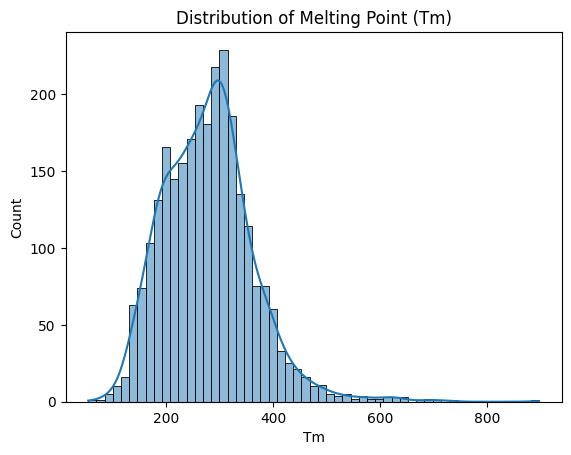

In [30]:
sns.histplot(df_train['Tm'], kde=True)
plt.title('Distribution of Melting Point (Tm)')

In [31]:
df_train['Tm'] = np.log1p(df_train['Tm'])

Text(0.5, 1.0, 'Log Distribution of Melting Point (Tm)')

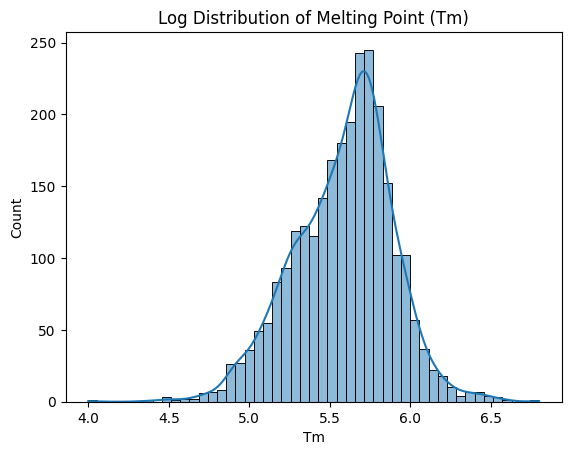

In [32]:
sns.histplot(df_train['Tm'], kde=True)
plt.title('Log Distribution of Melting Point (Tm)')

In [33]:
corr = df_train.corr(numeric_only=True)['Tm'].sort_values(ascending=False)
corr.head(20)



Tm           1.000000
Group 15     0.410309
Group 18     0.216845
Group 401    0.208596
Group 16     0.197800
Group 123    0.176931
Group 17     0.175985
Group 30     0.174721
Group 365    0.165625
Group 326    0.159609
Group 62     0.154296
Group 31     0.153609
Group 403    0.122929
Group 412    0.120711
Group 20     0.119341
Group 19     0.119282
Group 328    0.118480
Group 126    0.115667
Group 80     0.115400
Group 180    0.113840
Name: Tm, dtype: float64

In [34]:
df_train.var(numeric_only=True).sort_values(ascending=False).head(10)


id           912035.527317
Group 2          13.975755
Group 15          9.569500
Group 1           1.832343
Group 168         1.501046
Group 16          0.426149
Group 20          0.333788
Group 123         0.303399
Group 130         0.228351
Group 18          0.188419
dtype: float64

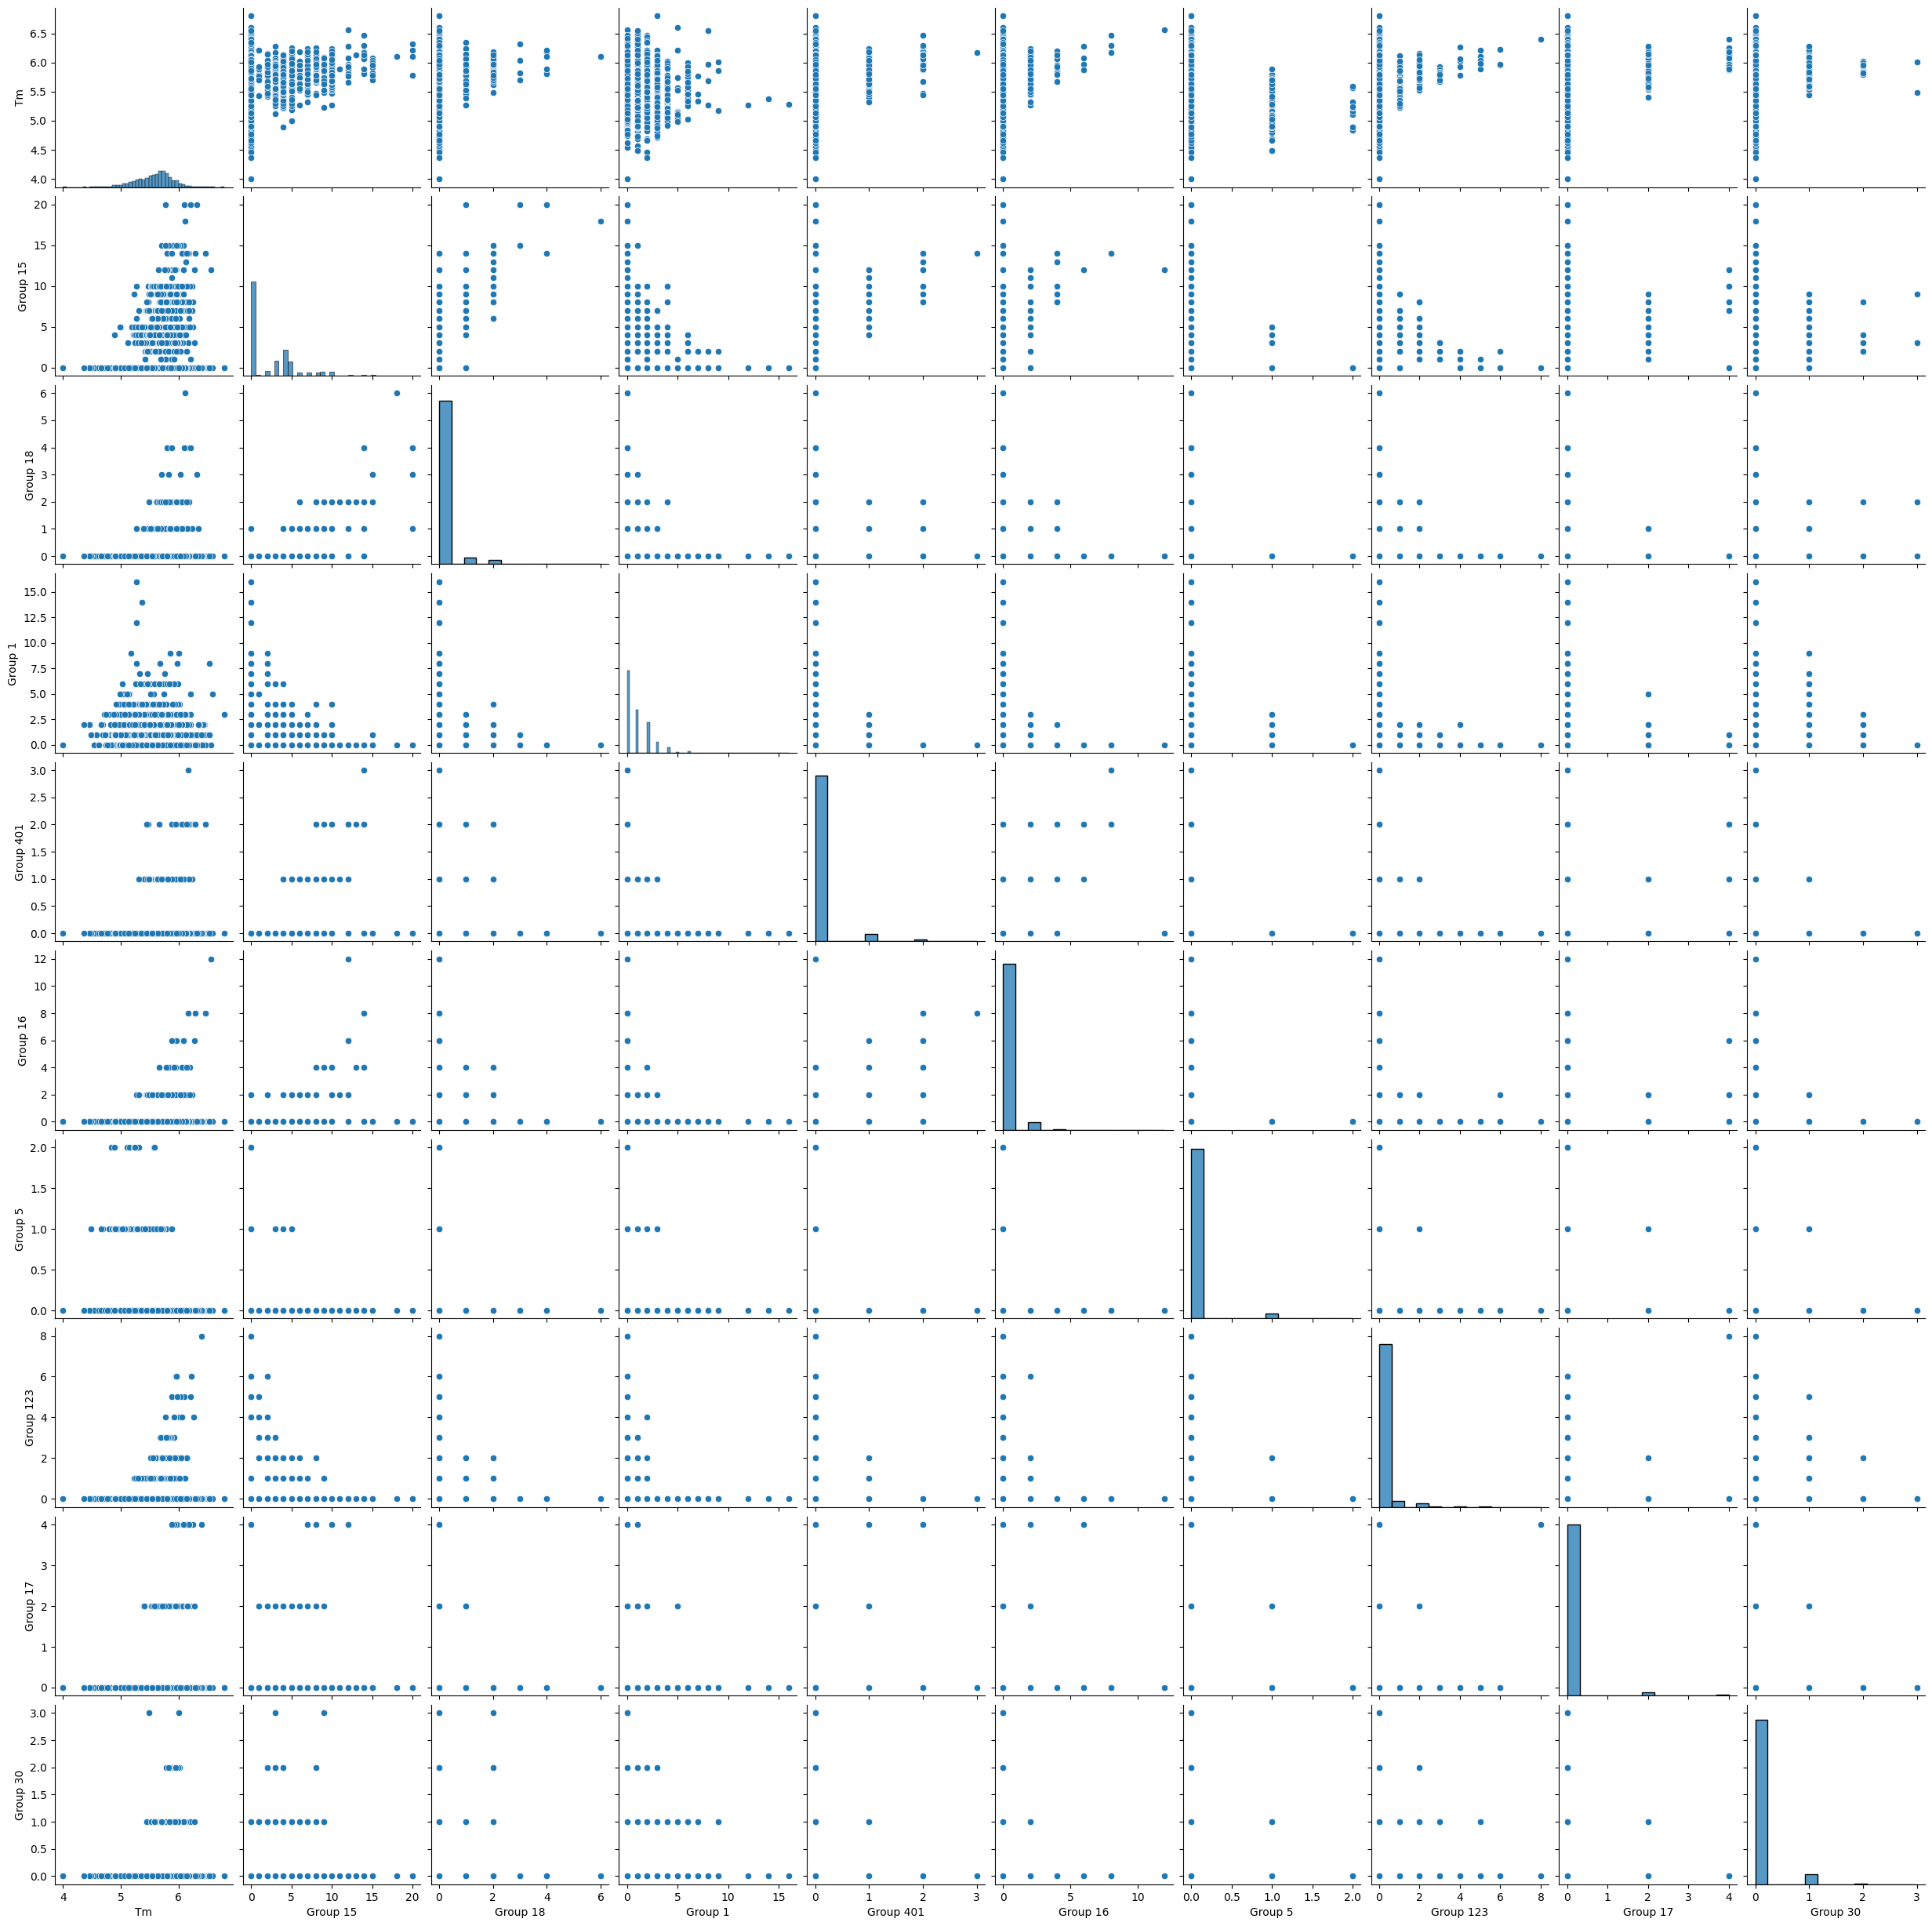

In [60]:
top_feats = corr.abs().sort_values(ascending=False).head(10).index
sns.pairplot(df_train[top_feats])


In [35]:
# Define proper fingerprint conversion
def smiles_to_morgan(smiles, radius=2, nBits=1024):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return np.zeros(nBits, dtype=int)
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits)
        arr = np.zeros((nBits,), dtype=int)
        DataStructs.ConvertToNumpyArray(fp, arr)
        return arr
    except:
        return np.zeros(nBits, dtype=int)

# Assuming df is your DataFrame with a 'SMILES' column
fingerprints = df_train['SMILES'].apply(smiles_to_morgan)

# Convert list of arrays into DataFrame
fp_df = pd.DataFrame(fingerprints.tolist(), columns=[f'fp_{i}' for i in range(1024)])

# Combine with original dataset (drop SMILES if not needed)
df_train = pd.concat([df_train.drop(columns=['SMILES']), fp_df], axis=1)

[23:12:49] DEPRECATION WARNING: please use MorganGenerator
[23:12:49] DEPRECATION WARNING: please use MorganGenerator
[23:12:49] DEPRECATION WARNING: please use MorganGenerator
[23:12:49] DEPRECATION WARNING: please use MorganGenerator
[23:12:49] DEPRECATION WARNING: please use MorganGenerator
[23:12:49] DEPRECATION WARNING: please use MorganGenerator
[23:12:49] DEPRECATION WARNING: please use MorganGenerator
[23:12:49] DEPRECATION WARNING: please use MorganGenerator
[23:12:49] DEPRECATION WARNING: please use MorganGenerator
[23:12:49] DEPRECATION WARNING: please use MorganGenerator
[23:12:49] DEPRECATION WARNING: please use MorganGenerator
[23:12:49] DEPRECATION WARNING: please use MorganGenerator
[23:12:49] DEPRECATION WARNING: please use MorganGenerator
[23:12:49] DEPRECATION WARNING: please use MorganGenerator
[23:12:49] DEPRECATION WARNING: please use MorganGenerator
[23:12:49] DEPRECATION WARNING: please use MorganGenerator
[23:12:49] DEPRECATION WARNING: please use MorganGenerat

In [38]:
print("Nonzero fingerprint bits:", fp_df.sum().sum())

Nonzero fingerprint bits: 41024


In [39]:
X = df_train.drop(columns = ['id', 'Tm'], axis = 1)
Y = df_train['Tm']

In [40]:
X

,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,Group 8,Group 9,Group 10,...,fp_1014,fp_1015,fp_1016,fp_1017,fp_1018,fp_1019,fp_1020,fp_1021,fp_1022,fp_1023
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2657,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2658,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2659,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2660,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [43]:
# Auto-detect + custom logic
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
fingerprint_features = [col for col in numeric_features if col.startswith('fp_')]
numeric_features = [col for col in numeric_features if col.startswith('Group')]
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Define transformers
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Column transformer (no feature selection)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('fp', 'passthrough', fingerprint_features)
    ]
)



In [49]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "XGBoost": XGBRegressor(random_state=42, n_estimators=200)
}

cv = KFold(n_splits = 5, shuffle = True, random_state = 43)

In [52]:
for name, model in models.items():
    pipe = Pipeline([
         ("preprocessor", preprocessor),
         ("regressor", model)
    ])

    
    scores = cross_val_score(pipe, X, Y, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)

    mae_scores = -scores

    print(f"\n{name}")
    print("MAE Scores:", mae_scores)
    print("Mean MAE:", mae_scores.mean())
    print("Std Dev:", mae_scores.std())


LinearRegression
MAE Scores: [0.25088024 0.22856016 0.23847986 0.23051665 0.25144721]
Mean MAE: 0.23997682559725889
Std Dev: 0.009721422646930126

Ridge
MAE Scores: [0.16356421 0.15620207 0.1508231  0.15208473 0.16093037]
Mean MAE: 0.1567208965036578
Std Dev: 0.004921338232080715

Lasso
MAE Scores: [0.23936638 0.25165107 0.23338143 0.25436907 0.24114102]
Mean MAE: 0.24398179300442138
Std Dev: 0.007854337079416957

ElasticNet
MAE Scores: [0.23936638 0.25165107 0.23338143 0.25436907 0.24114102]
Mean MAE: 0.24398179300442138
Std Dev: 0.007854337079416957

RandomForest
MAE Scores: [0.12360315 0.12870697 0.12255109 0.12759339 0.12125651]
Mean MAE: 0.12474222117468817
Std Dev: 0.002901625607576032

GradientBoosting
MAE Scores: [0.14573074 0.15407075 0.13803364 0.15049501 0.13482875]
Mean MAE: 0.14463177913685382
Std Dev: 0.007270681124272451

KNN
MAE Scores: [0.1744475  0.17370865 0.17060018 0.17662356 0.17639738]
Mean MAE: 0.1743554536951195
Std Dev: 0.0021836967247916648

SVR
MAE Scores: 

**FINAL MODEL - XGBOOST**

In [53]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 43)

In [55]:
final_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(random_state = 43, n_jobs =-1))
 
])


In [57]:
param_dist = {
    "regressor__n_estimators": [200, 500, 800],
    "regressor__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "regressor__max_depth": [3, 4, 5, 6, 8],
    "regressor__subsample": [0.6, 0.8, 1.0],
    "regressor__colsample_bytree": [0.6, 0.8, 1.0],
    "regressor__gamma": [0, 0.1, 0.3, 0.5],
    "regressor__reg_alpha": [0, 0.001, 0.01, 0.1, 1],
    "regressor__reg_lambda": [0.1, 0.5, 1, 2, 5],
    "regressor__min_child_weight": [1, 3, 5]
}


random_search = RandomizedSearchCV(
    final_pipe,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="neg_mean_absolute_error",  # use competition metric
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X, Y)

print("Best Parameters:", random_search.best_params_)
print("Best MAE:", -random_search.best_score_)  # Flip sign to get positive MAE

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'regressor__subsample': 1.0, 'regressor__reg_lambda': 5, 'regressor__reg_alpha': 0.001, 'regressor__n_estimators': 800, 'regressor__min_child_weight': 3, 'regressor__max_depth': 5, 'regressor__learning_rate': 0.2, 'regressor__gamma': 0, 'regressor__colsample_bytree': 1.0}
Best MAE: 0.12004116687246658


In [58]:
best_param = random_search.best_params_

for para, value in best_param.items():
    print(f"{para}:{value}\n")

regressor__subsample:1.0

regressor__reg_lambda:5

regressor__reg_alpha:0.001

regressor__n_estimators:800

regressor__min_child_weight:3

regressor__max_depth:5

regressor__learning_rate:0.2

regressor__gamma:0

regressor__colsample_bytree:1.0



In [59]:
final_model = Pipeline([
   ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(subsample = 1.0, reg_lambda = 5, reg_alpha = 0.001, n_estimators = 800,
                               min_child_weight = 3, max_depth = 5, learning_rate = 0.2,
                               gamma = 0, colsample_bytree = 1.0, random_state = 43, n_jobs =-1))
])


In [60]:
final_model.fit(X_train, Y_train)
pred = final_model.predict(X_test)

print("Evaluation Metrics: \n")
print(r2_score(Y_test, pred))
print(mean_absolute_error(Y_test, pred))
print(mean_squared_error(Y_test, pred))

Evaluation Metrics: 

0.7029148829550266
0.12184499117326371
0.02793517792057424


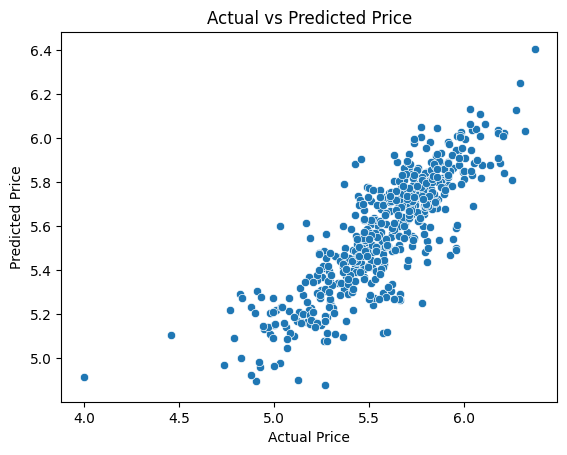

In [61]:
sns.scatterplot(x=Y_test, y=pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

In [62]:
df_test

,id,SMILES,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,Group 8,...,Group 415,Group 416,Group 417,Group 418,Group 419,Group 420,Group 421,Group 422,Group 423,Group 424
0,1022,CCOC(=O)c1ccc(O)cc1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1146,CCCCCCc1ccc(O)cc1O,1,4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,79,ClCBr,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2279,C=CCCCCCCCC,1,7,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1342,Fc1ccc(cc1)C(F)(F)F,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
661,2663,CCCCCCCCC(=O)CC,2,7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
662,624,COc1ccc(COC(=O)C)cc1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
663,2655,C#CCCC(C)C,2,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
664,2089,BrCC(Br)C(Br)C,1,1,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [64]:
# Define proper fingerprint conversion
def smiles_to_morgan(smiles, radius=2, nBits=1024):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return np.zeros(nBits, dtype=int)
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits)
        arr = np.zeros((nBits,), dtype=int)
        DataStructs.ConvertToNumpyArray(fp, arr)
        return arr
    except:
        return np.zeros(nBits, dtype=int)

# Assuming df is your DataFrame with a 'SMILES' column
fingerprints = df_test['SMILES'].apply(smiles_to_morgan)

# Convert list of arrays into DataFrame
fp_df = pd.DataFrame(fingerprints.tolist(), columns=[f'fp_{i}' for i in range(1024)])

# Combine with original dataset (drop SMILES if not needed)
df_test = pd.concat([df_test.drop(columns=['SMILES']), fp_df], axis=1)

[00:01:53] DEPRECATION WARNING: please use MorganGenerator
[00:01:53] DEPRECATION WARNING: please use MorganGenerator
[00:01:53] DEPRECATION WARNING: please use MorganGenerator
[00:01:53] DEPRECATION WARNING: please use MorganGenerator
[00:01:53] DEPRECATION WARNING: please use MorganGenerator
[00:01:53] DEPRECATION WARNING: please use MorganGenerator
[00:01:53] DEPRECATION WARNING: please use MorganGenerator
[00:01:53] DEPRECATION WARNING: please use MorganGenerator
[00:01:53] DEPRECATION WARNING: please use MorganGenerator
[00:01:53] DEPRECATION WARNING: please use MorganGenerator
[00:01:53] DEPRECATION WARNING: please use MorganGenerator
[00:01:53] DEPRECATION WARNING: please use MorganGenerator
[00:01:53] DEPRECATION WARNING: please use MorganGenerator
[00:01:53] DEPRECATION WARNING: please use MorganGenerator
[00:01:53] DEPRECATION WARNING: please use MorganGenerator
[00:01:53] DEPRECATION WARNING: please use MorganGenerator
[00:01:53] DEPRECATION WARNING: please use MorganGenerat

In [65]:
df_test

,id,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,Group 8,Group 9,...,fp_1014,fp_1015,fp_1016,fp_1017,fp_1018,fp_1019,fp_1020,fp_1021,fp_1022,fp_1023
0,1022,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1146,1,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,79,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2279,1,7,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1342,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
661,2663,2,7,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
662,624,1,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0
663,2655,2,2,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
664,2089,1,1,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [76]:

X_test = df_test.drop(columns=["id"])


y_pred_log = final_model.predict(X_test)
y_pred = np.expm1(y_pred_log)

results = pd.DataFrame({
    "id": df_test["id"],
    "Predicted": y_pred
})

results.head()


,id,Predicted
0,1022,338.088318
1,1146,308.368713
2,79,210.468567
3,2279,217.124191
4,1342,250.142029
